# Iris Flower Classification using Machine Learning

## Objective

The objective of this project is to develop a machine learning classification model that can classify Iris flowers into one of three species: Setosa, Versicolor, and Virginica. The classification is performed based on four flower measurements: sepal length, sepal width, petal length, and petal width. The project demonstrates the complete machine learning workflow, including data loading, exploration, visualization, model training, prediction, and performance evaluation.


## Importing the Dataset

The Iris dataset is imported from the Scikit-learn library. This dataset is one of the most popular datasets used for learning classification algorithms because it is clean, balanced, and contains measurements of three different Iris flower species.

In [20]:
from sklearn.datasets import load_iris

iris = load_iris()

## Understanding the Dataset

Before building a machine learning model, it is important to understand the dataset. In this step, we examine the available features, target classes, and the overall structure of the dataset. This helps us understand the information that will be used for prediction.


In [21]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [22]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [23]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


## Exploring the Dataset

The dataset is converted into a Pandas DataFrame to make it easier to read and analyze. Displaying the first few records allows us to verify that the dataset has been loaded correctly and understand the format of the available data.

In [24]:
print(iris.data[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [25]:
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [26]:
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Data Preprocessing and Statistical Analysis

The dataset is examined to check its structure, data types, missing values, and statistical summary. This step ensures that the data is clean and suitable for training a machine learning model. Since the Iris dataset contains no missing values, no additional preprocessing is required.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [28]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [29]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Data Visualization

Data visualization is performed to understand the relationship between different flower measurements. Scatter plots help identify patterns and show how well the three Iris species are separated based on their petal and sepal dimensions.

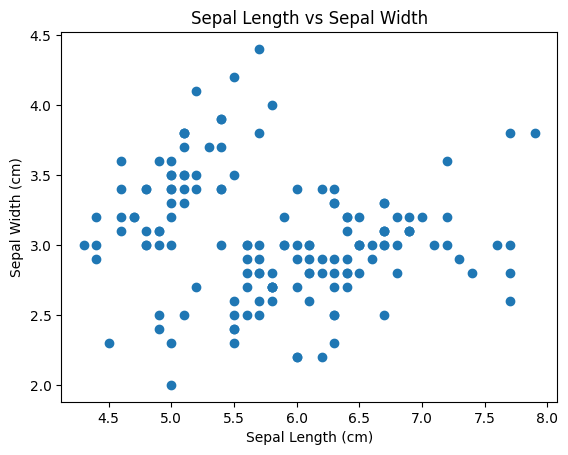

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")
plt.show()

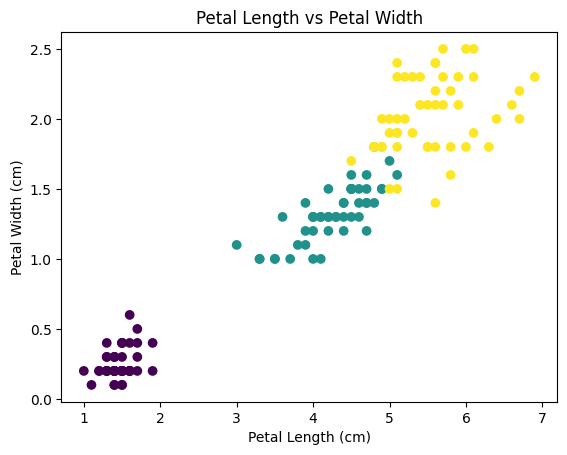

In [31]:
plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["target"]
)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.show()

## Feature and Target Selection

The dataset is divided into input features (X) and the target variable (y). The input features contain the flower measurements, while the target variable represents the species that the model will learn to predict.

In [32]:
X = df.drop("target", axis=1)
y = df["target"]

## Splitting the Dataset

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate how well the trained model performs on unseen data.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

A Logistic Regression classifier is used to train the model. During training, the algorithm learns the relationship between the flower measurements and their corresponding species so that it can classify new flowers accurately.

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Making Predictions

After the model has been trained, it is used to predict the species of the flowers present in the testing dataset. These predictions are then compared with the actual values to evaluate the model's performance.

In [35]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## Model Evaluation

The performance of the trained model is evaluated using Accuracy Score, Confusion Matrix, and Classification Report. These evaluation metrics help measure how accurately the model classifies the Iris flower species and provide detailed insights into its performance.

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Conclusion

In this project, the Iris Flower Classification model was developed using the Logistic Regression algorithm. The Iris dataset was explored, converted into a Pandas DataFrame, and checked for missing values. Data visualization was performed using scatter plots to understand the relationship between features. The dataset was then divided into training and testing sets, and the Logistic Regression model was trained.

The model achieved an accuracy of **100%** on the test dataset. The Confusion Matrix showed that all flower species were classified correctly, and the Classification Report indicated perfect Precision, Recall, and F1-Score for all three classes.

This project helped in understanding the complete machine learning classification workflow, including data exploration, preprocessing, model training, prediction, and evaluation.